# 这是房地产市场洞察项目
1. 导入库
2. 导入数据
3. 数据概览
4. 数据清洗
5. 新数据特征构造
6. 问题分析及可视化

### 1.导入库

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams

rcParams['font.family'] = 'Noto Sans CJK JP'  # 给linux用


### 2. 导入数据

In [33]:
df = pd.read_csv('../pandas/data/house_sales.csv')
df.tail()

,city,address,area,floor,name,price,province,rooms,toward,unit,year,origin_url
106113,鹤岗,南山区,73㎡,中层（共6层）,九州新建小区,12万,黑龙江,2室1厅,东西向,1644元/㎡,NaN,https://hegang.esf.fang.com/chushou/16_201235.htm
106114,鹤岗,-鹤岗市兴安区,70㎡,低层（共7层）,滨河南小区,21万,黑龙江,2室1厅,南北向,3000元/㎡,NaN,https://hegang.esf.fang.com/chushou/16_201234.htm
106115,鹤岗,-鹤岗市兴安区,70㎡,低层（共7层）,滨河南小区,21万,黑龙江,2室1厅,南北向,3000元/㎡,NaN,https://hegang.esf.fang.com/chushou/16_201234.htm
106116,鹤岗,工农区,64㎡,高层（共6层）,鹤岗市工农区原消防队三号楼,15万,黑龙江,2室1厅,南北向,2344元/㎡,NaN,https://hegang.esf.fang.com/chushou/16_201236.htm
106117,鹤岗,工农区,64㎡,高层（共6层）,鹤岗市工农区原消防队三号楼,15万,黑龙江,2室1厅,南北向,2344元/㎡,NaN,https://hegang.esf.fang.com/chushou/16_201236.htm


### 3. 数据概览

In [34]:
print('总记录数:', len(df))
print('总字段数量：', len(df.columns))
df.info()

总记录数: 106118
总字段数量： 12
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106118 entries, 0 to 106117
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   city        106118 non-null  object
 1   address     104452 non-null  object
 2   area        105324 non-null  object
 3   floor       104024 non-null  object
 4   name        105564 non-null  object
 5   price       105564 non-null  object
 6   province    106118 non-null  object
 7   rooms       104036 non-null  object
 8   toward      105240 non-null  object
 9   unit        105564 non-null  object
 10  year        57736 non-null   object
 11  origin_url  105564 non-null  object
dtypes: object(12)
memory usage: 9.7+ MB


### 4. 数据清洗

### 4.1 缺失值的处理

In [35]:
# 删除无用的数据列
df.drop(columns='origin_url', inplace=True)
df.head()

,city,address,area,floor,name,price,province,rooms,toward,unit,year
0,合肥,龙岗-临泉东路和王岗大道交叉口东南角,90㎡,中层（共18层）,圣地亚哥,128万,安徽,3室2厅,南北向,14222元/㎡,2013年建
1,合肥,龙岗-临泉东路和王岗大道交叉口东南角,90㎡,中层（共18层）,圣地亚哥,128万,安徽,3室2厅,南北向,14222元/㎡,2013年建
2,合肥,生态公园-淮海大道与大众路交口,95㎡,中层（共18层）,正荣·悦都荟,132万,安徽,3室2厅,南向,13895元/㎡,2019年建
3,合肥,生态公园-淮海大道与大众路交口,95㎡,中层（共18层）,正荣·悦都荟,132万,安徽,3室2厅,南向,13895元/㎡,2019年建
4,合肥,撮镇-文一名门金隅裕溪路与东风大道交口,37㎡,中层（共22层）,文一名门金隅,32万,安徽,2室1厅,南北向,8649元/㎡,2017年建


In [36]:
# 检查是否有缺失值
df.isna().sum()

# 删除缺失值数据
df.dropna(inplace=True)
print('删除后的数据还剩：', len(df))

删除后的数据还剩： 57520


In [37]:
# 检查重复值
df.duplicated().sum()

# 删除重复值
df.drop_duplicates(inplace=True)
print('删除后的数据还剩：', len(df))

删除后的数据还剩： 28104


In [38]:
# 表格中表示房屋面积的都带有单位㎡，删除单位方便后续进行计算
df['area'] = df['area'].str.replace('㎡', '').astype(float)
df.head()

,city,address,area,floor,name,price,province,rooms,toward,unit,year
0,合肥,龙岗-临泉东路和王岗大道交叉口东南角,90.0,中层（共18层）,圣地亚哥,128万,安徽,3室2厅,南北向,14222元/㎡,2013年建
2,合肥,生态公园-淮海大道与大众路交口,95.0,中层（共18层）,正荣·悦都荟,132万,安徽,3室2厅,南向,13895元/㎡,2019年建
4,合肥,撮镇-文一名门金隅裕溪路与东风大道交口,37.0,中层（共22层）,文一名门金隅,32万,安徽,2室1厅,南北向,8649元/㎡,2017年建
6,合肥,龙岗-长江东路与和县里交口,50.0,高层（共30层）,柏庄金座,46万,安徽,2室1厅,南向,9200元/㎡,2019年建
8,合肥,新亚汽车站-张洼路与临泉路交汇处向北100米(原红星机械,120.0,中层（共27层）,天目未来,158万,安徽,4室2厅,南向,13167元/㎡,2012年建


In [39]:
# 价格要去掉单位万
df['price'] = df['price'].str.replace('万', '').astype(float)
df.head()

,city,address,area,floor,name,price,province,rooms,toward,unit,year
0,合肥,龙岗-临泉东路和王岗大道交叉口东南角,90.0,中层（共18层）,圣地亚哥,128.0,安徽,3室2厅,南北向,14222元/㎡,2013年建
2,合肥,生态公园-淮海大道与大众路交口,95.0,中层（共18层）,正荣·悦都荟,132.0,安徽,3室2厅,南向,13895元/㎡,2019年建
4,合肥,撮镇-文一名门金隅裕溪路与东风大道交口,37.0,中层（共22层）,文一名门金隅,32.0,安徽,2室1厅,南北向,8649元/㎡,2017年建
6,合肥,龙岗-长江东路与和县里交口,50.0,高层（共30层）,柏庄金座,46.0,安徽,2室1厅,南向,9200元/㎡,2019年建
8,合肥,新亚汽车站-张洼路与临泉路交汇处向北100米(原红星机械,120.0,中层（共27层）,天目未来,158.0,安徽,4室2厅,南向,13167元/㎡,2012年建


In [40]:
# 房屋朝向类型转换
df['toward'] = df['toward'].astype('category')

In [41]:
# 每平米的价格去掉元/㎡
df['unit'] = df['unit'].str.replace('元/㎡', '').astype(float)
df.head()

,city,address,area,floor,name,price,province,rooms,toward,unit,year
0,合肥,龙岗-临泉东路和王岗大道交叉口东南角,90.0,中层（共18层）,圣地亚哥,128.0,安徽,3室2厅,南北向,14222.0,2013年建
2,合肥,生态公园-淮海大道与大众路交口,95.0,中层（共18层）,正荣·悦都荟,132.0,安徽,3室2厅,南向,13895.0,2019年建
4,合肥,撮镇-文一名门金隅裕溪路与东风大道交口,37.0,中层（共22层）,文一名门金隅,32.0,安徽,2室1厅,南北向,8649.0,2017年建
6,合肥,龙岗-长江东路与和县里交口,50.0,高层（共30层）,柏庄金座,46.0,安徽,2室1厅,南向,9200.0,2019年建
8,合肥,新亚汽车站-张洼路与临泉路交汇处向北100米(原红星机械,120.0,中层（共27层）,天目未来,158.0,安徽,4室2厅,南向,13167.0,2012年建


In [42]:
# 建造年份需要处理
df['year'] = df['year'].str.replace('年建', '').astype(int)
df.head()

,city,address,area,floor,name,price,province,rooms,toward,unit,year
0,合肥,龙岗-临泉东路和王岗大道交叉口东南角,90.0,中层（共18层）,圣地亚哥,128.0,安徽,3室2厅,南北向,14222.0,2013
2,合肥,生态公园-淮海大道与大众路交口,95.0,中层（共18层）,正荣·悦都荟,132.0,安徽,3室2厅,南向,13895.0,2019
4,合肥,撮镇-文一名门金隅裕溪路与东风大道交口,37.0,中层（共22层）,文一名门金隅,32.0,安徽,2室1厅,南北向,8649.0,2017
6,合肥,龙岗-长江东路与和县里交口,50.0,高层（共30层）,柏庄金座,46.0,安徽,2室1厅,南向,9200.0,2019
8,合肥,新亚汽车站-张洼路与临泉路交汇处向北100米(原红星机械,120.0,中层（共27层）,天目未来,158.0,安徽,4室2厅,南向,13167.0,2012


### 4.2 异常值的处理

In [43]:
# 面积的异常
print('面积太小房屋：\n', df[df['area'] < 20])
print('面积太大的房屋：\n', df[df['area'] > 600])

df = df[(df['area'] > 20) & (df['area'] < 600)]

面积太小房屋：
        city                address   area     floor     name  price province  \
102      合肥         新省府-包河大道与南京路交口  11.00  中层（共27层）   招商·雍华府   22.0       安徽   
980      天津         体育馆街-成都道与桂林路交口  11.86   高层（共1层）    成都道小区  140.0      直辖市   
6366     杭州  北干-天汇园星云地带新区金城路金鸡路交叉处  17.00  中层（共28层）  天汇园星云地带   50.0       浙江   
8388     丽水  北郭桥/白云-莲都-北郭桥/白云-汽运宿舍  17.00   高层（共1层）     汽运宿舍   48.0       浙江   
28798    毕节         黔西县-黔西南部新区教育园区  11.00  低层（共31层）    黔西阳光城   42.0       贵州   
40546    巢湖         新省府-包河大道与南京路交口  11.00  中层（共27层）   招商·雍华府   22.0       安徽   
40886    蚌埠               张公山-红旗一路  15.00   低层（共7层）   朝阳新村三村   24.5       安徽   
40892    蚌埠          淮河路-胜利东路1556号  10.00  中层（共11层）     百合公馆  132.0       安徽   
50780    泸州       蓝田-江阳区-蓝田-江阳区-蓝田  18.00   中层（共2层）   江阳区-蓝田   35.0       四川   
68686    开阳             小十字-飞山街42号  14.00  低层（共23层）    飞山街小区   13.0       贵州   
80478    孝感    中心城区-孝南-中心城区-润达壹号广场  10.00  低层（共16层）   润达壹号广场   14.0       湖北   
94170    清镇          紫林庵-飞山街中医二

In [44]:
# 房屋售价的异常处理
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df = df[(df['price'] > lower_bound) & (df['price'] < upper_bound)]

### 5. 新数据特征构造
- 构造新的列

In [45]:
# 区名district
df['district'] = df['address'].str.split('-').str[0]  # 取 split 之后列表里的第一个元素
df.sample(5)

,city,address,area,floor,name,price,province,rooms,toward,unit,year,district
83360,岳阳,岳阳楼城区-岳阳楼-岳阳楼城区-洞庭国际半岛公园,100.00,低层（共30层）,洞庭国际半岛公园,50.8,湖南,3室2厅,南北向,5080.0,2019,岳阳楼城区
98134,文昌,老城-老城经济开发区南海大道21公里处,58.00,高层（共18层）,四季康城二期,57.0,海南,1室2厅,南北向,9828.0,2015,老城
23550,金堂,华阳-天府大道与正北下街交汇处(三利云锦旁),36.00,中层（共23层）,美高登A座,52.0,四川,1室1厅,南向,14444.0,2015,华阳
92884,滦县,凤凰新城-长宁道与光明路交叉口,104.96,中层（共33层）,橡树湾,220.0,河北,3室2厅,南北向,20960.0,2014,凤凰新城
894,上海,浦江-浦连路598弄,55.43,中层（共17层）,金硕河畔景园(南区),170.0,直辖市,1室1厅,南向,30669.0,2013,浦江


In [46]:
# 楼层类型floor_type
def fun1(str1):
    if pd.isna(str1):
        return '未知'
    elif '低' in str1:
        return '低楼层'
    elif '中' in str1:
        return '中楼层'
    elif '高' in str1:
        return '高楼层'
    else:
        return '未知'


df['floor_type'] = df['floor'].apply(fun1).astype('category')
df.sample(5)

,city,address,area,floor,name,price,province,rooms,toward,unit,year,district,floor_type
28556,雅安,雨城区-新生路65号,81.7,低层（共7层）,新生路65号,56.0,四川,3室2厅,南北向,6854.0,2000,雨城区,低楼层
50532,农安,劳动公园-万科蓝山长春市二道区东盛大街666号,92.4,低层（共34层）,万科蓝山,114.0,吉林,2室2厅,南北向,12338.0,2014,劳动公园,低楼层
22114,长清,齐鲁软件园-雅居园崇华路1587号,136.0,中层（共18层）,雅居园,269.0,山东,3室2厅,南北向,19779.0,2010,齐鲁软件园,中楼层
28906,毕节,黔西县-黔西同心商贸城对面,110.0,低层（共31层）,十里春风,43.0,贵州,3室2厅,南北向,3909.0,2019,黔西县,低楼层
15342,招远,"三滩社区-长安路以东、观海路以西,市委党校以南、金滩东",92.0,低层（共26层）,飞龙金滩花园,116.0,山东,2室2厅,南北向,12609.0,2020,三滩社区,低楼层


In [47]:
# 是否为直辖市 is_municipality
df['is_municipality'] = df['city'].apply(lambda x: 1 if x in ['北京', '天津', '上海', '重庆'] else 0)
df.sample(5)

,city,address,area,floor,name,price,province,rooms,toward,unit,year,district,floor_type,is_municipality
96934,韶关,南郊-南郊6公里北江中路(海事局旁),123.00,高层（共25层）,锦绣明珠园,83.0,广东,3室2厅,南北向,6748.0,2015,南郊,高楼层,0
12264,潍坊,潍坊一中-高新城市广场健康街与潍安路交叉口西南角,152.00,中层（共21层）,高新城市广场,125.0,山东,3室2厅,南向,8224.0,2017,潍坊一中,中楼层,0
94910,绵阳,经开区-经开区绵州大道1号,110.00,高层（共30层）,神州南都,83.8,四川,3室2厅,东南向,7618.0,2015,经开区,高楼层,0
34940,泰安,泰安东区-创业大街西段,175.54,高层（共5层）,华新社区,156.0,山东,4室2厅,南北向,8887.0,2004,泰安东区,高楼层,0
94852,南充,北干道-南充市环都大道北侧,108.79,高层（共23层）,金色愿景,87.0,四川,3室2厅,南北向,7997.0,2015,北干道,高楼层,0


In [48]:
# 卧室数量 bedrooms
df['bedrooms'] = df['rooms'].str.split('室').str[0].astype(int)
df.sample(5)

,city,address,area,floor,name,price,province,rooms,toward,unit,year,district,floor_type,is_municipality,bedrooms
74972,南阳,高新区-北外环路与健康路交汇处(农运会馆北侧),103.50,低层（共13层）,鑫泰公园道,105.0,河南,2室2厅,西向,10145.0,2014,高新区,低楼层,0,2
55114,清徐,亲贤-亲贤街92号,133.50,中层（共16层）,水总宿舍,165.0,山西,3室2厅,南北向,12360.0,2008,亲贤,中楼层,0,3
101494,邕宁,高新开发区-科园大道52号(桂盐科技园旁),87.03,高层（共32层）,科瑞江韵,83.0,广西,2室2厅,南向,9537.0,2015,高新开发区,高楼层,0,2
49960,泸州,蓝田-泸州市蓝安路与绕城路杨桥连接线交汇处,92.00,低层（共32层）,天远红树湾,53.8,四川,3室2厅,南向,5848.0,2018,蓝田,低楼层,0,3
61330,昌黎,南戴河-宁海道东205国道南200米(原万博文化城),93.00,中层（共18层）,保利海公园,81.0,河北,2室2厅,南北向,8710.0,2016,南戴河,中楼层,0,2


In [49]:
# 客厅数量 livingrooms
df['livingrooms'] = df['rooms'].str.extract(r'(\d+)厅').astype(int)
df.sample(5)

,city,address,area,floor,name,price,province,rooms,toward,unit,year,district,floor_type,is_municipality,bedrooms,livingrooms
742,天津,东海街-学苑路与双水道交口东侧,45.9,中层（共6层）,珠峰里,113.0,直辖市,1室1厅,南向,24619.0,1998,东海街,中楼层,1,1,1
40818,巢湖,农业示范园-合肥经开区天都路与云谷路交叉口东南角,95.0,中层（共32层）,熔安家园,106.0,安徽,2室2厅,南北向,11158.0,2015,农业示范园,中楼层,0,2,2
3724,大连,滨海路-滨海大道与赤峰街交汇处,101.0,中层（共37层）,恒大公园大道,137.0,辽宁,2室2厅,南北向,13564.0,2018,滨海路,中楼层,0,2,2
61422,昌黎,北戴河其他-站南大街以南、戴河支路二十三以北、规划戴河三,83.0,中层（共6层）,海滨胜境,69.0,河北,2室2厅,南北向,8313.0,2019,北戴河其他,中楼层,0,2,2
12592,汕头,中山东路-韩江路南侧42街区,129.0,高层（共32层）,尚海阳光,191.0,广东,3室2厅,东南向,14806.0,2013,中山东路,高楼层,0,3,2


In [50]:
# 楼龄 building_age
df['building_age'] = 2026 - df['year']
df.sample(5)

,city,address,area,floor,name,price,province,rooms,toward,unit,year,district,floor_type,is_municipality,bedrooms,livingrooms,building_age
462,芜湖,其他-长江北路与广福路交叉口西侧500米,134.0,中层（共17层）,万科江东府,163.00,安徽,3室2厅,南向,12164.0,2019,其他,中楼层,0,3,2,7
22250,靖安,袁州区-江西省宜春市袁州区宜阳北路618号,113.0,中层（共12层）,紫竹庭院,72.00,江西,3室2厅,南北向,6372.0,2012,袁州区,中楼层,0,3,2,14
63736,肥东,奥体中心-政务区金寨南路与潜山路交叉口,47.0,中层（共28层）,中辰优唐广场,54.13,安徽,3室2厅,南北向,11517.0,2018,奥体中心,中楼层,0,3,2,8
42758,德阳,城北-翠湖花园峨眉南路二段159号,159.0,中层（共6层）,翠湖花园,106.60,四川,3室2厅,南向,6704.0,2007,城北,中楼层,0,3,2,19
59486,玉田,远洋城-祥和里唐山市华岩北路与朝阳道交叉口,49.3,中层（共6层）,祥和里,59.00,河北,1室1厅,南北向,11968.0,2000,远洋城,中楼层,0,1,1,26


In [51]:
# 价格分段 price_labels
df['price_labels'] = pd.cut(df['price'], bins=4, labels=['低价', '中等价', '高价', '豪华'])
df.sample(5)

,city,address,area,floor,name,price,province,rooms,toward,unit,year,district,floor_type,is_municipality,bedrooms,livingrooms,building_age,price_labels
80848,信阳,新七大道-信阳市新七大道与工六路交汇处,118.0,低层（共17层）,泰阳辰,66.0,河南,3室2厅,南北向,5593.0,2020,新七大道,低楼层,0,3,2,6,低价
16768,慈溪,慈溪其他-慈溪-慈溪其他-明峰健康城,48.0,高层（共11层）,明峰健康城,35.0,浙江,2室2厅,南北向,7292.0,2017,慈溪其他,高楼层,0,2,2,9,低价
55992,苏州,滨湖新城-迎春南路与花港路交汇处东侧(迎春华府南侧),104.0,低层（共18层）,伟业迎春乐家,190.0,江苏,3室2厅,南向,18269.0,2016,滨湖新城,低楼层,0,3,2,10,高价
5792,金华,婺城新区-白龙桥镇十二局,54.0,高层（共6层）,华电新村十二局,33.8,浙江,2室1厅,南北向,6259.0,1990,婺城新区,高楼层,0,2,1,36,低价
15472,珠海,唐家湾-唐家湾情侣北路(南段)3663号,95.0,低层（共32层）,仁恒滨海半岛,270.0,广东,3室2厅,南向,28421.0,2019,唐家湾,低楼层,0,3,2,7,豪华


### 6. 问题分析及可视化

问题编号:A1
问题:哪些变量最影响房价?面积、楼层、房间数哪个影响更大?
- 分析主题:特征相关性
- 分析目标:了解房屋各特征对房价的线性影响
- 分组字段:无
- 指标/方法:皮尔逊相关系数

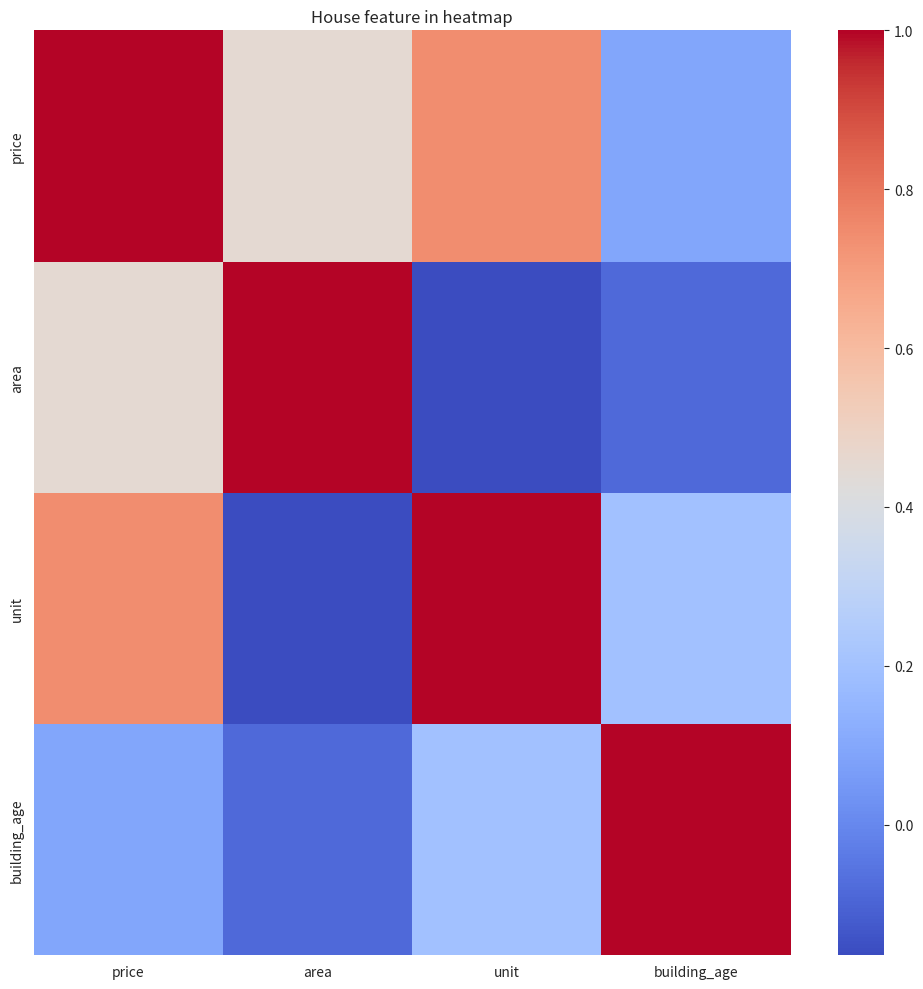

In [52]:
# 选择数据特征，计算相关系数
a = df[['price', 'area', 'unit', 'building_age']].corr()
# 对房价影响最大的几个因素
a['price'].sort_values(ascending=False)[1:]
# 画相关性的热力图
plt.figure(figsize=(10, 10))
sns.heatmap(a, cmap='coolwarm')
plt.title('House feature in heatmap')
plt.tight_layout()

问题编号:A2
问题:全国房价总体分布是怎样的?
- 分析主题:描述性统计
- 分析目标:概览数值型字段的分布特征
- 分组字段:无
- 指标/方法:平均数/中位数/四分位数/标准差

In [53]:
df.describe()

,area,price,unit,year,is_municipality,bedrooms,livingrooms,building_age
count,26135.000000,26135.000000,26135.000000,26135.000000,26135.000000,26135.000000,26135.000000,26135.000000
mean,103.755810,117.208370,11610.131012,2013.072240,0.008800,2.714444,1.848556,12.927760
std,33.995994,60.967675,5824.245273,6.019342,0.093399,0.800768,0.407353,6.019342
min,21.000000,9.000000,1000.000000,1976.000000,0.000000,0.000000,0.000000,3.000000
25%,85.005000,72.000000,7587.000000,2011.000000,0.000000,2.000000,2.000000,9.000000
50%,100.000000,103.000000,10312.000000,2015.000000,0.000000,3.000000,2.000000,11.000000
75%,123.000000,150.000000,14184.000000,2017.000000,0.000000,3.000000,2.000000,15.000000
max,470.000000,306.000000,85288.000000,2023.000000,1.000000,9.000000,12.000000,50.000000


(array([ 3650., 10135.,  6490.,  3174.,  1703.,   983.]),
 array([  9. ,  58.5, 108. , 157.5, 207. , 256.5, 306. ]),
 <BarContainer object of 6 artists>)

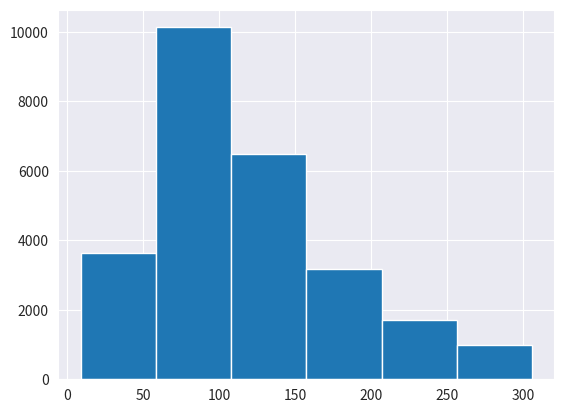

In [54]:
# 房价分布的直方图
plt.subplot(111)
plt.hist(df['price'], bins=6)


<Axes: xlabel='price', ylabel='Count'>

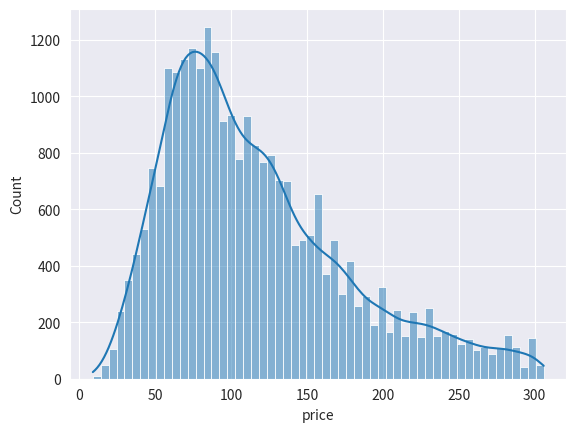

In [55]:
sns.histplot(data=df, x='price', kde=True)

问题编号:A6
问题:南北向是否真比单一朝向贵?贵多少?
- 分析主题:朝向溢价
- 分析目标:评估不同朝向的价格差异
- 分组字段: toward
- 指标/方法:方差分析/多重比较

In [56]:
df.groupby('toward').agg({
    'price': ['mean', 'median'],
    'unit': 'median',
    'building_age': 'mean',
})

/tmp/ipykernel_1409/1639256807.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('toward').agg({


price            unit building_age
              mean median   median         mean
toward                                         
东北向     114.555333  100.0  12198.0    13.609524
东南向     115.542608  105.0  10864.0    11.951745
东向      110.158568   95.0  11421.0    13.761337
东西向      98.935099   82.0   9000.0    16.490066
北向       92.527907   75.5  11698.0    14.108527
南北向     119.472147  104.5  10000.0    13.073703
南向      114.555016  103.0  10759.0    12.551160
西北向     119.107594  105.0  12290.0    14.473684
西南向     139.711811  138.4  13333.0    14.452756
西向      102.662298   86.0  12528.0    14.385093

<Axes: xlabel='toward', ylabel='price'>

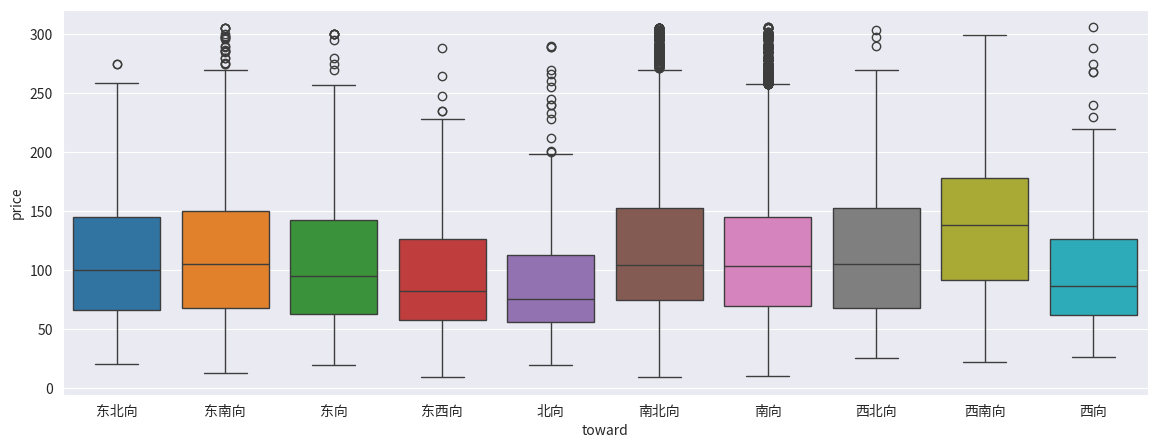

In [57]:
plt.figure(figsize=(14, 5))
sns.boxplot(x='toward', y='price', hue='toward', data=df)